In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # Estadistica avanzada

In [2]:
# Definir configuracion de lienzo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 12

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## <center> PREPROCESAMIENTO </center>

In [ ]:
df.shape[0] # calcula el numero de filas

891

In [ ]:
df.shape[1] # calcula el numero de columnas

15

In [6]:
df.shape[0] * df.shape[1] # calcula el numero de elementos

13365

In [11]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [10]:
f"{df.memory_usage(deep=True).sum() / 1024:.2f} KB"  # en KB

'278.87 KB'

#####  <center> Despues de revisar que todos los tipos de datos, corresponden a lo esperado, <br>  podemos proceder a analizar los datos faltantes en el conjunto de datos. </center>  

In [13]:
df.isnull().sum() / df.shape[0] * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

<Axes: >

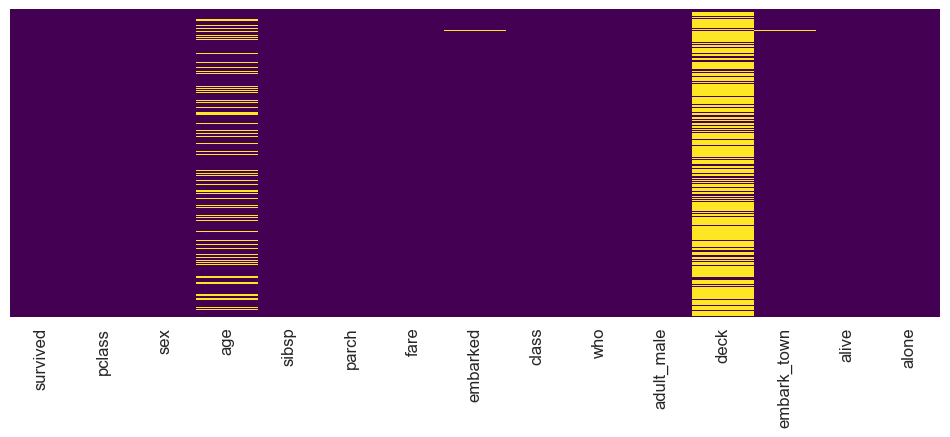

In [14]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

### Recuerden la estrategia de nulos en las clases anteriores para el manejo de datos faltantes. 
### Yo voy a repararlos simples, pero se altera la distribución de los datos.

In [15]:
# Crear una funcion que dependiendo del tipo de dato, repara los nulos por la media, moda o mediana 
def reparar_nulos(df):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'float64' or df[col].dtype == 'int64':
                # Repara con la mediana
                df[col].fillna(df[col].median(), inplace=True)
            else:
                # Repara con la moda
                df[col].fillna(df[col].mode()[0], inplace=True)
    return df

In [16]:
reparar_nulos(df)

/var/folders/br/fsrfqv0n0g941rv2mjgbrf6h0000gn/T/ipykernel_46306/1968234740.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/br/fsrfqv0n0g941rv2mjgbrf6h0000gn/T/ipykernel_46306/1968234740.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,C,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,C,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [18]:
df.duplicated().sum() # siempre comprobar los duplicados

np.int64(112)

##### Estudiar las filas duplicadas y ver si es necesario eliminarlas.

In [ ]:
df.isnull().sum() # siempre comprobar los nulos despues de repararlos

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

### <center> EDA - Análisis Exploratorio de Datos </center>

In [22]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

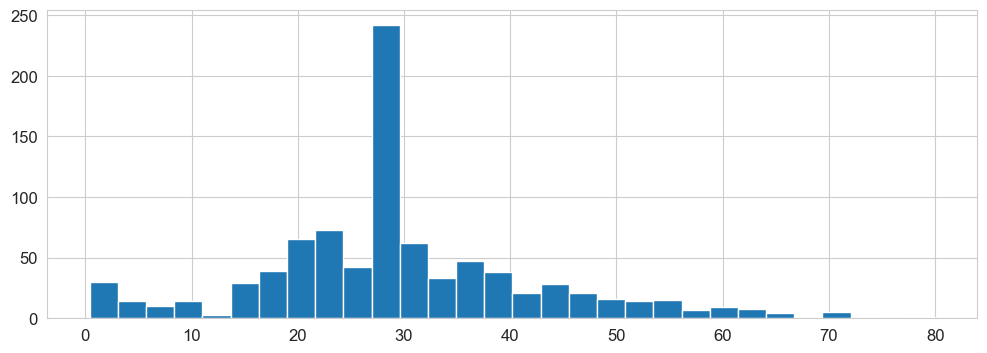

In [23]:
df['age'].hist(bins=30)

#### Test de normalidad

In [34]:
stat_age, p_age = stats.shapiro(df['age']) #Shapiro-Wilk test , es ideal para muestras pequeñas (<5000)
print(f"Estadístico de prueba: {stat_age}, p-valor: {p_age:.16f}")
if p_age > 0.05:
    print("La distribución de 'age' es normal.")
else:
    print("La distribución de 'age' no es normal.") 

Estadístico de prueba: 0.9541046573646541, p-valor: 0.0000000000000005
La distribución de 'age' no es normal.


In [ ]:
stat_fare , p_fare = stats.normaltest(df['fare']) # D'Agostino and Pearson's test , es ideal para muestras grandes (>20)
print(f"Estadístico de prueba: {stat_fare}, p-valor: {p_fare:.33f}")
if p_fare > 0.05: #USENLO CUANTO LAS MUESTRAS SEAN MAYOR A >5000
    print("La distribución de 'fare' es normal.")
else:
    print("La distribución de 'fare' no es normal.")

Estadístico de prueba: 904.5872705326926, p-valor: 0.000000000000000000000000000000000
La distribución de 'fare' no es normal.


In [29]:
#como es la correlacion de age con fare
corr_age_fare = df['age'].corr(method='spearman', other=df['fare'])
print(f"La correlación entre 'age' y 'fare' es: {corr_age_fare}")

La correlación entre 'age' y 'fare' es: 0.12600552124010062


In [ ]:
# Muchas veces descubrimos relaciones en los datos aplicando el test correcto segun la distribucion 

/var/folders/br/fsrfqv0n0g941rv2mjgbrf6h0000gn/T/ipykernel_46306/4150980588.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['class'], y=df['age'], ax=ax[2], palette='pastel')


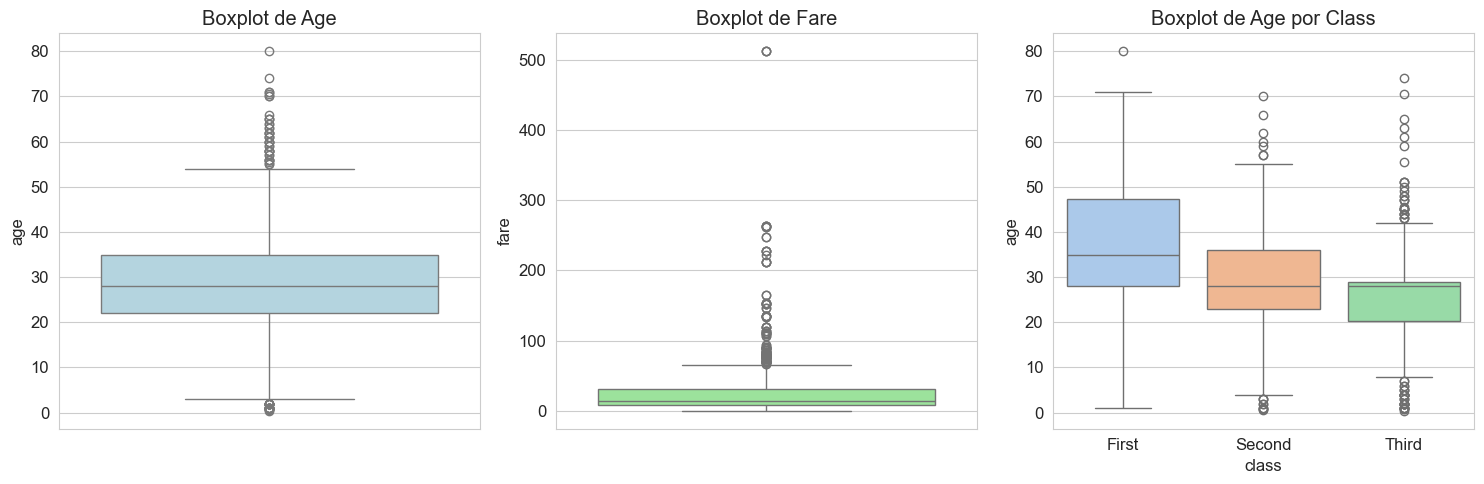

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

#boxplot de age 
sns.boxplot(y=df['age'], ax=ax[0], color='lightblue')
ax[0].set_title('Boxplot de Age')
#boxplot de fare
sns.boxplot(y=df['fare'], ax=ax[1], color='lightgreen')
ax[1].set_title('Boxplot de Fare')
#boxplot horizontal de age por class
sns.boxplot(x=df['class'], y=df['age'], ax=ax[2], palette='pastel')
ax[2].set_title('Boxplot de Age por Class')
plt.tight_layout()
plt.show()

### Distr no es normal usamos IQR para outliers

In [40]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

In [41]:
detect_outliers_iqr(df, 'fare')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,C,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,0,3,male,28.0,8,2,69.5500,S,Third,man,True,C,Southampton,no,False
849,1,1,female,28.0,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,C,Southampton,yes,False
863,0,3,female,28.0,8,2,69.5500,S,Third,woman,False,C,Southampton,no,False


In [42]:
detect_outliers_iqr(df, 'age')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
7,0,3,male,2.00,3,1,21.0750,S,Third,child,False,C,Southampton,no,False
11,1,1,female,58.00,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
15,1,2,female,55.00,0,0,16.0000,S,Second,woman,False,C,Southampton,yes,True
16,0,3,male,2.00,4,1,29.1250,Q,Third,child,False,C,Queenstown,no,False
33,0,2,male,66.00,0,0,10.5000,S,Second,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,1,2,male,1.00,0,2,37.0042,C,Second,child,False,C,Cherbourg,yes,False
829,1,1,female,62.00,0,0,80.0000,S,First,woman,False,B,Southampton,yes,True
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,C,Southampton,yes,False
851,0,3,male,74.00,0,0,7.7750,S,Third,man,True,C,Southampton,no,True


### Si nuestra distribución es normal usamos Z-score para outliers

In [43]:
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column]))
    outliers = data[z_scores > threshold]
    return outliers

In [44]:
detect_outliers_iqr(df, 'fare')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,28.0,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,C,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,0,3,male,28.0,8,2,69.5500,S,Third,man,True,C,Southampton,no,False
849,1,1,female,28.0,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,C,Southampton,yes,False
863,0,3,female,28.0,8,2,69.5500,S,Third,woman,False,C,Southampton,no,False


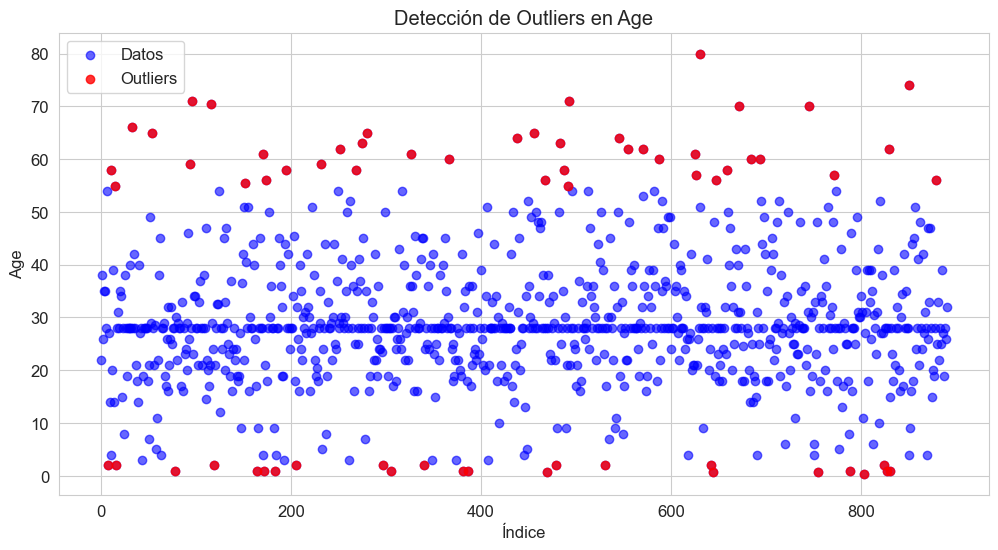

In [46]:
#scatter plot con outliers marcados de age
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

axes.scatter(df.index, df['age'], label='Datos', color='blue', alpha=0.6)
outliers_age = detect_outliers_iqr(df, 'age')
axes.scatter(outliers_age.index, outliers_age['age'], label='Outliers', color='red', alpha=0.8)
axes.set_title('Detección de Outliers en Age')
axes.set_xlabel('Índice')
axes.set_ylabel('Age')
axes.legend()    
plt.show()

### Estrategias de reparacion de outliers

In [51]:
len(df)

891

#### Ojo, nunca alterar el df original, siempre trabajar sobre copias.

In [52]:
df_copia = df.copy()

In [50]:
#Eliminacion de outliers ( USAR CON CUIDADO )
def eliminar_outliers_iqr(data, column1, column2=None, column3=None, column4=None):
    cleaned_data = data.copy()
    columns = [column1, column2, column3, column4]
    
    for column in columns:
        if column is not None:
            Q1 = cleaned_data[column].quantile(0.25)
            Q3 = cleaned_data[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            cleaned_data = cleaned_data[(cleaned_data[column] >= lower_bound) & (cleaned_data[column] <= upper_bound)]
    
    return cleaned_data

cleaned_df = eliminar_outliers_iqr(df, 'age', 'fare', 'sibsp', 'parch')
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {cleaned_df.shape}")

Original DataFrame shape: (891, 15)
Cleaned DataFrame shape: (577, 15)


#### Winsorizing ( Reemplazar outliers por el valor del límite superior o inferior )


In [54]:
def winsorize_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    
    return data

In [55]:
df_winsorized = winsorize_outliers_iqr(df_copia, 'fare')
df_winsorized = winsorize_outliers_iqr(df_winsorized, 'age')


In [56]:
len(df_winsorized)

891

### Ojo, mal aplicado , falsea los datos

/var/folders/br/fsrfqv0n0g941rv2mjgbrf6h0000gn/T/ipykernel_46306/499927421.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_winsorized['class'], y=df_winsorized['age'], ax=ax[2], palette='pastel')


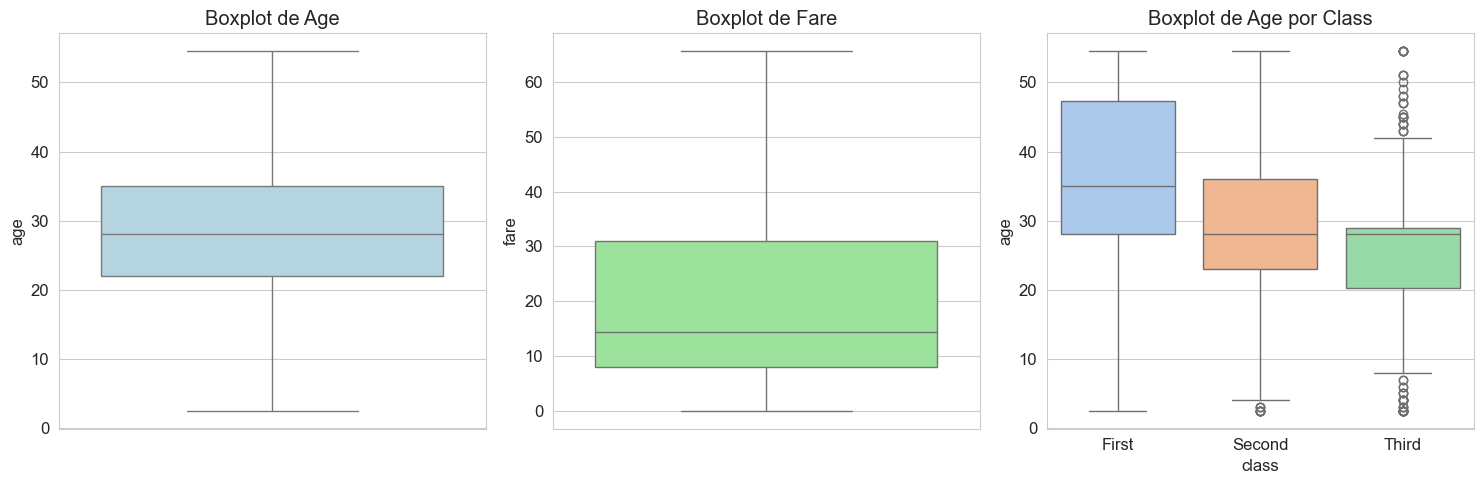

In [57]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

#boxplot de age 
sns.boxplot(y=df_winsorized['age'], ax=ax[0], color='lightblue')
ax[0].set_title('Boxplot de Age')
#boxplot de fare
sns.boxplot(y=df_winsorized['fare'], ax=ax[1], color='lightgreen')
ax[1].set_title('Boxplot de Fare')
#boxplot horizontal de age por class
sns.boxplot(x=df_winsorized['class'], y=df_winsorized['age'], ax=ax[2], palette='pastel')
ax[2].set_title('Boxplot de Age por Class')
plt.tight_layout()
plt.show()

#### Transformaciones logarítmicas
##### Esto actua sobre la distribución de los datos, no sobre los outliers en si.


### Se suele usar mas en variables financieras como los ingresos ( income ) o precios ( price ), y para machinas de aprendizaje ( ML ) que para análisis estadísticos tradicionales.

In [58]:
def log_transform(data, column):
    data[column] = np.log1p(data[column])  # log1p para manejar ceros
    return data

df_log = log_transform(df.copy(), 'fare')
df_log = log_transform(df_log, 'age')

<Axes: >

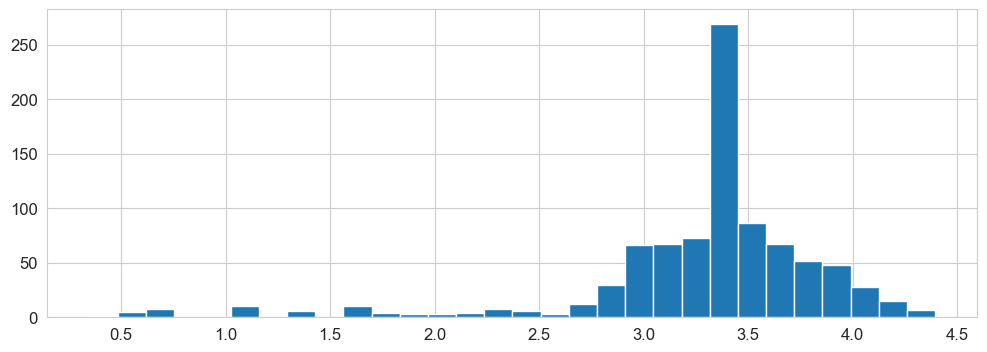

In [59]:
df_log['age'].hist(bins=30)

### Escaldo robusto ( Robust Scaling )


In [60]:
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
df_robust = df.copy()
df_robust[['age', 'fare']] = robust_scaler.fit_transform(df_robust[['age', 'fare']])

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fare'}>]], dtype=object)

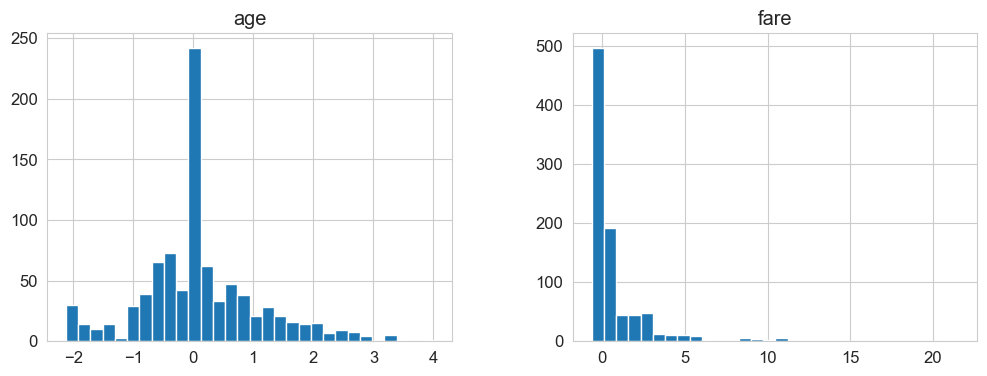

In [61]:
df_robust[['age', 'fare']].hist(bins=30)

### Correlación entre variables (numéricas)

In [62]:
correlation_matrix = df.select_dtypes(include=[np.number]).corr(method='spearman')
correlation_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.339668,-0.037004,0.088879,0.138266,0.323736
pclass,-0.339668,1.000000,-0.317406,-0.043019,-0.022801,-0.688032
age,-0.037004,-0.317406,1.000000,-0.145316,-0.217488,0.126006
sibsp,0.088879,-0.043019,-0.145316,1.000000,0.450014,0.447113
parch,0.138266,-0.022801,-0.217488,0.450014,1.000000,0.410074
fare,0.323736,-0.688032,0.126006,0.447113,0.410074,1.000000


<Axes: >

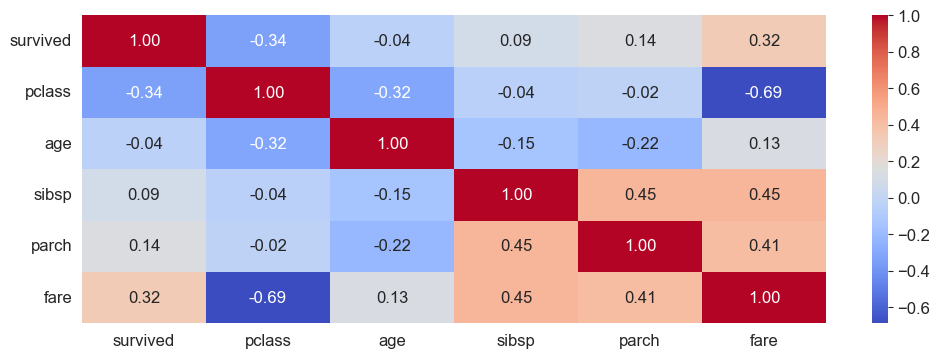

In [64]:
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')

##### R=1 : Correlación positiva perfecta
##### R=0.7 a 0.9 : Correlación positiva fuerte
##### R=0.4 a 0.6 : Correlación positiva moderada
##### R=0.1 a 0.3 : Correlación positiva débil
##### R=-1 : Correlación negativa perfecta
##### R=-0.7 a -0.9 : Correlación negativa fuerte
##### R=-0.4 a -0.6 : Correlación negativa moderada
##### R=-0.1 a -0.3 : Correlación negativa débil
##### R=0 : No hay correlación lineal entre las variables


In [63]:
target_corr = correlation_matrix['survived'].sort_values(ascending=False)
target_corr

survived    1.000000
fare        0.323736
parch       0.138266
sibsp       0.088879
age        -0.037004
pclass     -0.339668
Name: survived, dtype: float64

### Visualizar correlaciones

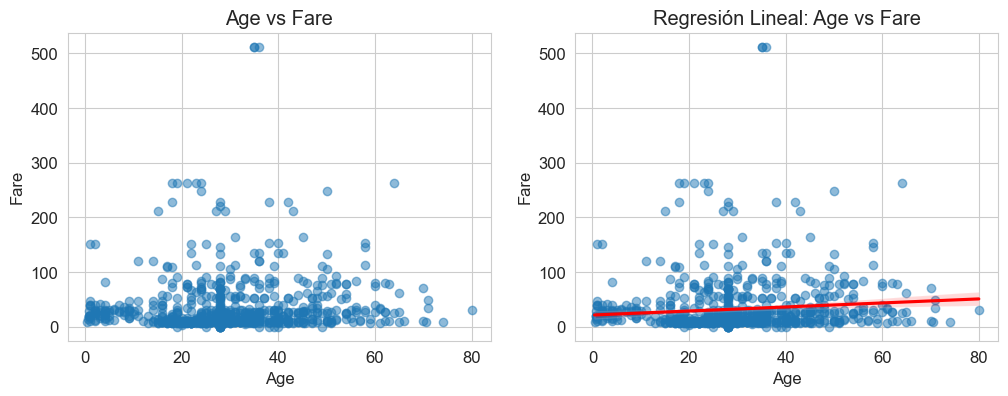

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['age'], df['fare'], alpha=0.5)
axes[0].set_title('Age vs Fare')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare')
sns.regplot(x='age', y='fare', data=df, ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Regresión Lineal: Age vs Fare')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare')
plt.show()

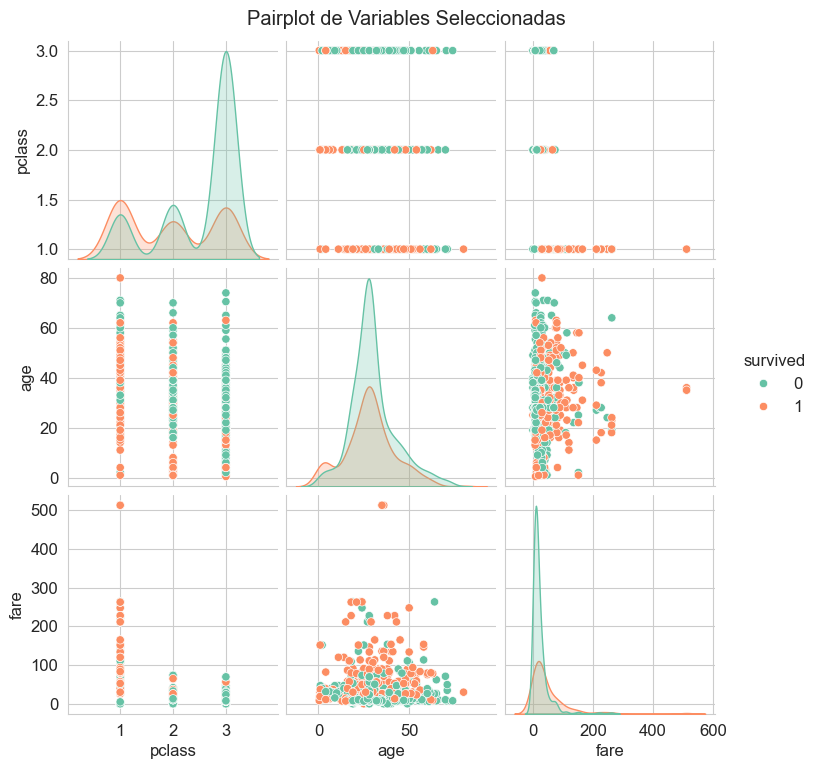

In [71]:
select_columns = ['survived', 'pclass', 'age', 'fare']
g = sns.pairplot(df[select_columns], hue='survived', diag_kind='kde', palette='Set2')
g.fig.suptitle('Pairplot de Variables Seleccionadas', y=1.02)
plt.show()

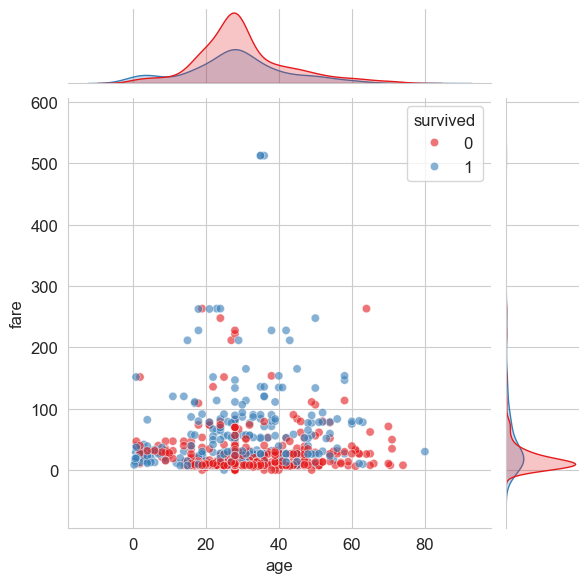

In [72]:
g = sns.jointplot(x='age', y='fare', data=df, kind='scatter', hue='survived', palette='Set1', alpha=0.6)
plt.show()

#### Relacion entre variables categoricas 

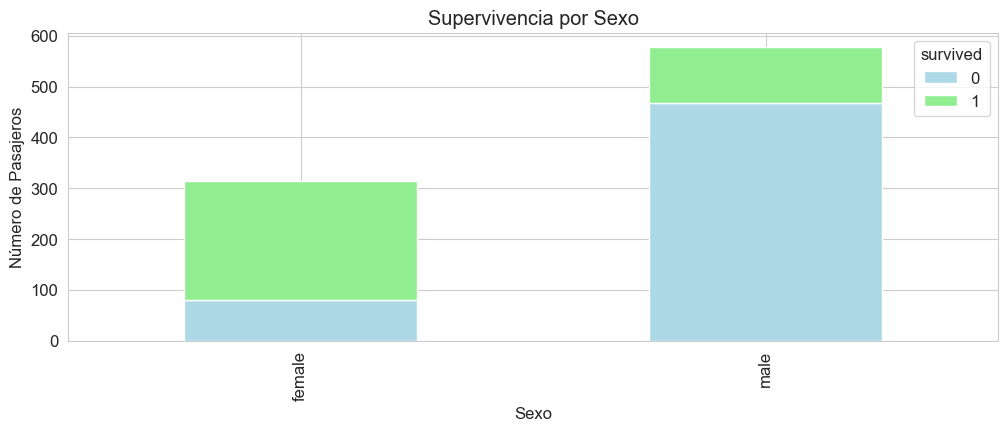

In [73]:
# Tabla de contingencia : sex y survived
contingency_table = pd.crosstab(df['sex'], df['survived'])
contingency_table
contingency_table.plot(kind='bar', stacked=True, color=['lightblue', 'lightgreen'])
plt.title('Supervivencia por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de Pasajeros')
plt.show()

In [75]:
contingency_table = pd.crosstab(df['sex'], df['survived'])
chi2_pclass , p_class, dof_pclass, expected_pclass = stats.chi2_contingency(contingency_table)
print(f"Chi-cuadrado: {chi2_pclass}, p-valor: {p_class}, Grados de libertad: {dof_pclass}")
if p_class < 0.05:
    print("Existe una asociación significativa entre el sexo y la supervivencia.")
else:
    print("No existe una asociación significativa entre el sexo y la supervivencia.")

Chi-cuadrado: 260.71702016732104, p-valor: 1.197357062775565e-58, Grados de libertad: 1
Existe una asociación significativa entre el sexo y la supervivencia.


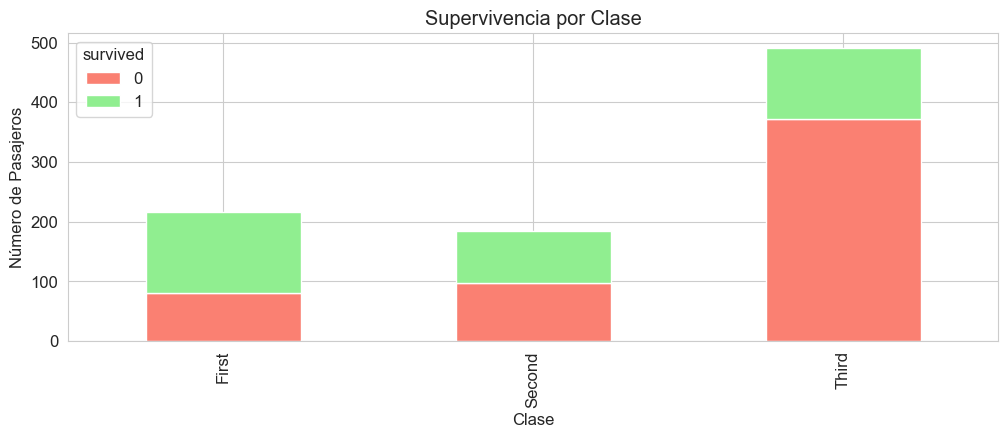

In [74]:
# Contingencia entre class y survived
contingency_table_class = pd.crosstab(df['class'], df['survived'])
contingency_table_class.plot(kind='bar', stacked=True, color=['salmon', 'lightgreen'])
plt.title('Supervivencia por Clase')
plt.xlabel('Clase')
plt.ylabel('Número de Pasajeros')
plt.show()

## GUÍA DE SELECCIÓN DE GRÁFICOS

| Tipo de Variable(s) | Objetivo | Gráfico Recomendado |
|---------------------|----------|---------------------|
| 1 Numérica continua | Ver distribución | Histograma + KDE |
| 1 Numérica continua | Detectar outliers | Boxplot |
| 1 Numérica continua | Distribución detallada | Violinplot |
| 1 Categórica | Ver frecuencias | Barplot |
| 2 Numéricas | Ver correlación | Scatter plot |
| 2 Numéricas | Correlación + distribuciones | Joint plot |
| N Numéricas | Correlaciones múltiples | Heatmap de correlación |
| N Numéricas | Relaciones pairwise | Pairplot |
| 1 Numérica + 1 Categórica | Comparar distribuciones | Boxplot o Violinplot por grupo |
| 2 Categóricas | Ver relaciones | Stacked bar chart o Heatmap |
| Valores nulos | Detectar patrones | Heatmap de nulos |
| Outliers | Visualizar anomalías | Scatter plot con marcadores |